# Exercise 08 - Finding Palm Lines using OpenCV

**Objective:** Upload your own palm image in **Google Colab** and highlight the major palm lines using:

- Grayscale conversion
- CLAHE contrast enhancement
- Bilateral filtering
- Black-hat morphology
- Canny edge detection
- Morphological cleanup
- Overlay visualization

> This is for **image processing practice only**. It detects visible lines/creases; it does not perform palm reading.

## Step 1: Setup

Run this cell first. It imports OpenCV, NumPy, Matplotlib, and defines helper functions.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

def show_bgr(img, title="Image", size=(8, 6)):
    '''Display a BGR/OpenCV image correctly inside Colab.'''
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(img, title="Image", size=(8, 6)):
    '''Display a grayscale image inside Colab.'''
    plt.figure(figsize=size)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def resize_keep_aspect(img, max_width=900):
    '''Resize large images so processing is faster and display is neat.'''
    h, w = img.shape[:2]
    if w <= max_width:
        return img
    scale = max_width / w
    new_size = (max_width, int(h * scale))
    return cv2.resize(img, new_size, interpolation=cv2.INTER_AREA)

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## Step 2: Upload your palm image

Upload a clear palm image from your computer.

**Best image tips:**
- Use a plain background
- Keep the palm open and close to the camera
- Avoid too much shadow
- Use `.jpg`, `.jpeg`, or `.png`

Saving palm.jpeg to palm.jpeg
Uploaded file: palm.jpeg
Image shape: (1200, 900, 3)


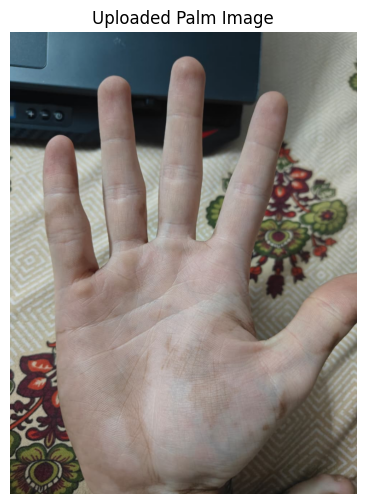

In [2]:
from google.colab import files

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No image uploaded. Please upload one palm image.")

filename = list(uploaded.keys())[0]

# Read uploaded image directly from memory
image_bytes = np.frombuffer(uploaded[filename], np.uint8)
palm = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)

if palm is None:
    raise ValueError("Could not read the uploaded file. Please upload a valid JPG/PNG image.")

palm = resize_keep_aspect(palm, max_width=900)

print("Uploaded file:", filename)
print("Image shape:", palm.shape)

show_bgr(palm, "Uploaded Palm Image")

## Step 3: Preprocess the image

Here we convert the image to grayscale and improve contrast so the palm lines become clearer.

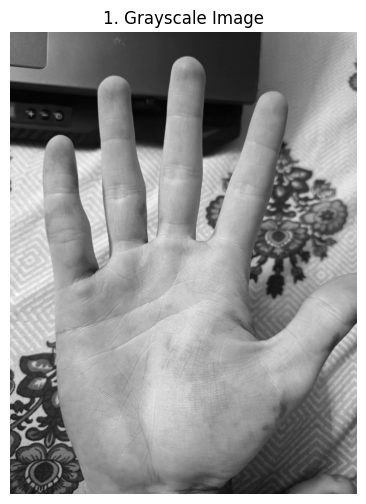

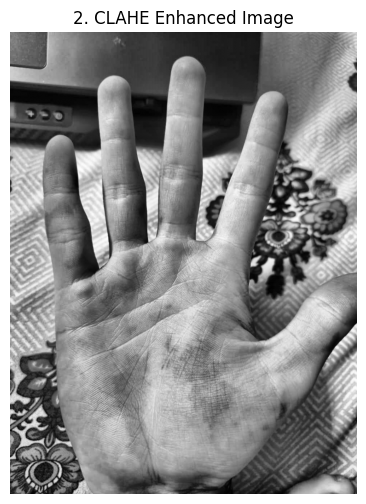

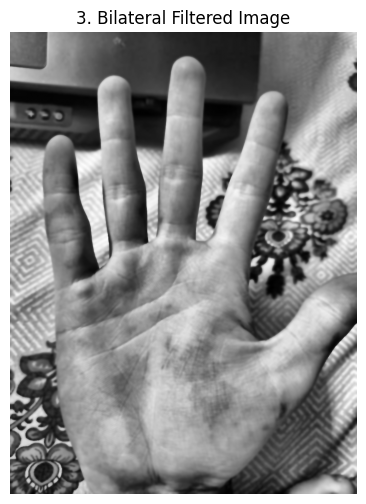

In [3]:
# Convert to grayscale
gray = cv2.cvtColor(palm, cv2.COLOR_BGR2GRAY)

# CLAHE improves local contrast and makes faint palm lines more visible
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
enhanced = clahe.apply(gray)

# Bilateral filter reduces noise while keeping edges/lines sharper
filtered = cv2.bilateralFilter(enhanced, d=9, sigmaColor=75, sigmaSpace=75)

show_gray(gray, "1. Grayscale Image")
show_gray(enhanced, "2. CLAHE Enhanced Image")
show_gray(filtered, "3. Bilateral Filtered Image")

## Step 4: Detect palm lines

This cell uses two methods together:

1. **Black-hat morphology** highlights dark thin lines on the palm.  
2. **Canny edge detection** detects sharp edges and creases.

Then both results are combined.

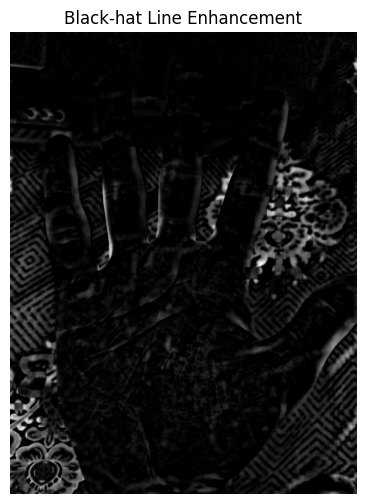

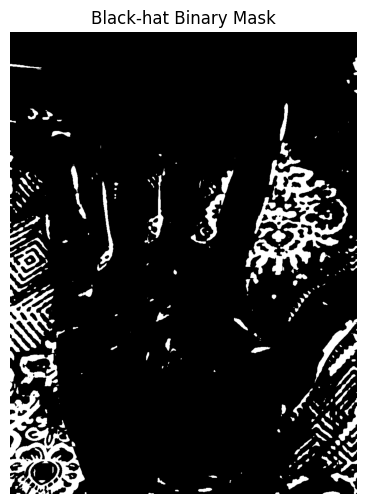

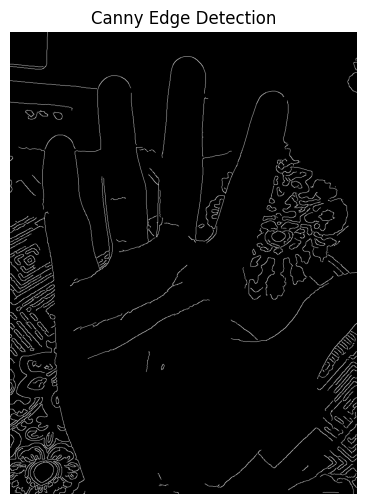

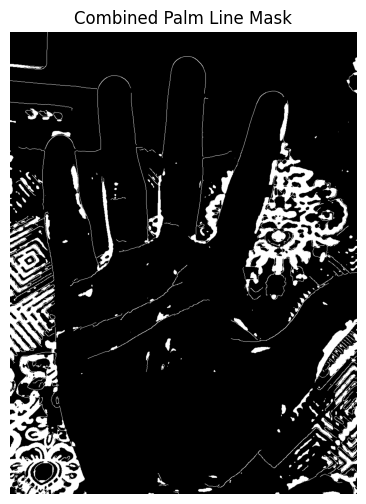

In [4]:
# Tune these values if your result is too noisy or too light
BLACKHAT_KERNEL_SIZE = 21
CANNY_LOW = 35
CANNY_HIGH = 110

# Black-hat transformation: useful for dark lines on a lighter palm surface
kernel_blackhat = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (BLACKHAT_KERNEL_SIZE, BLACKHAT_KERNEL_SIZE)
)
blackhat = cv2.morphologyEx(filtered, cv2.MORPH_BLACKHAT, kernel_blackhat)
blackhat = cv2.normalize(blackhat, None, 0, 255, cv2.NORM_MINMAX)

# Convert blackhat output into a binary line mask using Otsu thresholding
_, blackhat_mask = cv2.threshold(
    blackhat,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

# Canny edges
edges = cv2.Canny(filtered, CANNY_LOW, CANNY_HIGH)

# Combine both line masks
combined_mask = cv2.bitwise_or(blackhat_mask, edges)

show_gray(blackhat, "Black-hat Line Enhancement")
show_gray(blackhat_mask, "Black-hat Binary Mask")
show_gray(edges, "Canny Edge Detection")
show_gray(combined_mask, "Combined Palm Line Mask")

## Step 5: Clean the mask using morphology

Morphological operations remove small noise and connect broken line parts.

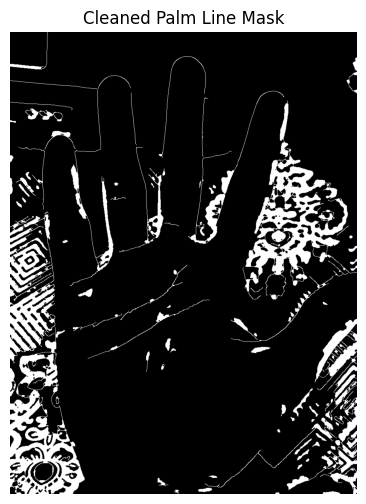

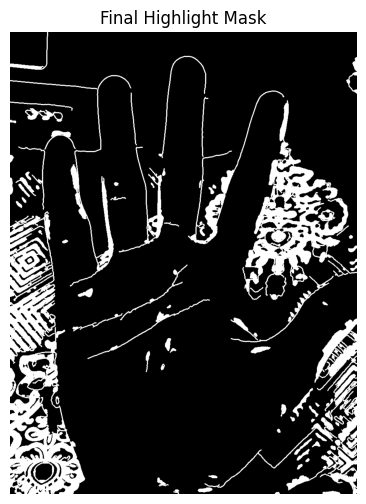

In [5]:
def remove_small_components(mask, min_area=35):
    '''Remove tiny connected components that are likely noise.'''
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area:
            clean[labels == label] = 255

    return clean

# Close small gaps in palm lines
kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
clean_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel_close, iterations=1)

# Remove small noisy dots
clean_mask = remove_small_components(clean_mask, min_area=35)

# Slight dilation makes final highlighted lines more visible
highlight_mask = cv2.dilate(clean_mask, kernel_close, iterations=1)

show_gray(clean_mask, "Cleaned Palm Line Mask")
show_gray(highlight_mask, "Final Highlight Mask")

## Step 6: Highlight palm lines on the original image

The detected palm lines are drawn on top of the original image.

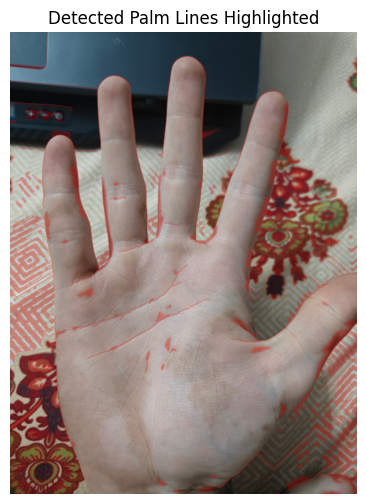

In [6]:
overlay = palm.copy()

# Red highlight in OpenCV BGR format
overlay[highlight_mask > 0] = (0, 0, 255)

# Blend original image and overlay for a neat result
result = cv2.addWeighted(palm, 0.75, overlay, 0.25, 0)

show_bgr(result, "Detected Palm Lines Highlighted")

## Step 7: Save and download output

This saves:
- `palm_lines_highlighted.png`
- `palm_line_mask.png`

In [7]:
output_image = "palm_lines_highlighted.png"
output_mask = "palm_line_mask.png"

cv2.imwrite(output_image, result)
cv2.imwrite(output_mask, highlight_mask)

print("Saved:", output_image)
print("Saved:", output_mask)

files.download(output_image)
files.download(output_mask)

Saved: palm_lines_highlighted.png
Saved: palm_line_mask.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Optional tuning

If your output is not perfect:

- If there is **too much noise**, increase `min_area` in Step 5.
- If lines are **too faint**, reduce `CANNY_LOW` and `CANNY_HIGH` in Step 4.
- If background edges are getting detected, use a clearer image with a plain background.
- If lines are too thick, reduce dilation iterations in Step 5.